# Viterbi Algorithm Implementation for Nature Primer

## Problem Statement
implements the Viterbi algorithm 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math
from collections import defaultdict
import pandas as pd
import seaborn as sns

## 1. Define Model Parameters

The HMM consists of:
- States: E (exon), I (intron), and 5 (5' splice site)
- Transition probabilities between states
- Emission probabilities for each state



In [2]:
# Define states
states = ['E', '5', 'I']

# Define possible observations (DNA nucleotides)
observations = ['A', 'C', 'G', 'T']

# Define initial probabilities
initial_probs = {
    'E': 1.0,
    '5': 0.0,
    'I': 0.0
}

# Define transition probabilities (as described in the Nature Primer) P(next state | current state)
transition_probs = {
    'E': {'E': 0.9, '5': 0.1, 'I': 0.0},
    '5': {'E': 0.0, '5': 0.0, 'I': 1.0},
    'I': {'E': 0.1, '5': 0.0, 'I': 0.9}
}

# Define emission probabilities (as described in the Nature Primer) P(observation | state)
emission_probs = {
    'E': {'A': 0.25, 'C': 0.25, 'G': 0.25, 'T': 0.25},  # Equal probability in exons
    '5': {'A': 0.05, 'C': 0.0, 'G': 0.95, 'T': 0.0},    # 5' splice site prefers G
    'I': {'A': 0.4, 'C': 0.1, 'G': 0.1, 'T': 0.4}       # Introns prefer A and T
}

for state in states:
    assert abs(sum(transition_probs[state].values()) - 1.0) < 1e-10, f"Transition probs for {state} don't sum to 1"
    assert abs(sum(emission_probs[state].values()) - 1.0) < 1e-10, f"Emission probs for {state} don't sum to 1"

print("Model parameters defined and validated.")

Model parameters defined and validated.


## 2. Function to Calculate Log Probability of a Given Path and Sequence


In [4]:
def get_log_prob_of_a_given_path(path, sequence):
    if len(path) != len(sequence):
        raise ValueError(f"Path length ({len(path)}) must match sequence length ({len(sequence)})")
    
    log_prob = 0.0
    log_prob += math.log(initial_probs[path[0]])
    log_prob += math.log(emission_probs[path[0]][sequence[0]])
    
    for i in range(1, len(path)):
        log_prob += math.log(transition_probs[path[i-1]][path[i]])
        log_prob += math.log(emission_probs[path[i]][sequence[i]])
    return log_prob

# Test
test_path = "EEEEEEEEEEEEEEEEEE5IIIIIII"
test_sequence = "CTTCATGTGAAAGCAGACGTAAGTCA"

log_prob = get_log_prob_of_a_given_path(test_path, test_sequence)
print(f"Log probability: {log_prob:.2f}")
print(f"Expected output: -41.22")
print(f"Difference: {abs(log_prob + 41.22):.4f}")

Log probability: -38.92
Expected output: -41.22
Difference: 2.3029


## 3. Viterbi Algorithm Implementation


In [5]:
def viterbi(sequence):
    V = [{}]  # Viterbi matrix
    path = {}
    
    # Initialize the base case (first observation)
    for state in states:
        # Initial probability * emission probability
        if initial_probs[state] > 0 and emission_probs[state][sequence[0]] > 0:
            V[0][state] = math.log(initial_probs[state]) + math.log(emission_probs[state][sequence[0]])
        else:
            V[0][state] = float('-inf')  # Log of zero is negative infinity
        path[state] = [state]
    
    for t in range(1, len(sequence)):
        V.append({})
        new_path = {}
        
        for curr_state in states:
            max_prob = float('-inf')
            best_prev_state = None
            
            for prev_state in states:
                if V[t-1][prev_state] == float('-inf') or transition_probs[prev_state][curr_state] == 0:
                    continue
                
                prob = V[t-1][prev_state] + math.log(transition_probs[prev_state][curr_state])
                
                if prob > max_prob:
                    max_prob = prob
                    best_prev_state = prev_state
            
            if best_prev_state is not None:
                if emission_probs[curr_state][sequence[t]] > 0:
                    V[t][curr_state] = max_prob + math.log(emission_probs[curr_state][sequence[t]])
                    new_path[curr_state] = path[best_prev_state] + [curr_state]
                else:
                    V[t][curr_state] = float('-inf')
            else:
                V[t][curr_state] = float('-inf')
        
        path = new_path
    
    max_prob = float('-inf')
    best_final_state = None
    
    for state in states:
        if V[-1][state] > max_prob:
            max_prob = V[-1][state]
            best_final_state = state
    
    most_likely_path = ''.join(path[best_final_state]) if best_final_state else ''
    return most_likely_path, max_prob

# Test with the example sequence
test_sequence = "CTTCATGTGAAAGCAGACGTAAGTCA"
most_likely_path, log_prob = viterbi(test_sequence)

print(f"Observed sequence: {test_sequence}")
print(f"Most likely path: {most_likely_path}")
print(f"Log probability: {log_prob:.2f}")

Observed sequence: CTTCATGTGAAAGCAGACGTAAGTCA
Most likely path: EEEEEEEEEEEEEEEEEEEEEEEEEE
Log probability: -38.68


## 4. Visualization and Analysis

Let's visualize the results to better understand the algorithm.
This will help us compare the manually specified path with the most likely path found by Viterbi.

In [6]:
def compare_paths(sequence, viterbi_path, manual_path):
    df = pd.DataFrame({
        'Position': range(1, len(sequence) + 1),
        'Nucleotide': list(sequence),
        'Viterbi Path': list(viterbi_path),
        'Manual Path': list(manual_path)
    })
    
    viterbi_prob = get_log_prob_of_a_given_path(viterbi_path, sequence)
    manual_prob = get_log_prob_of_a_given_path(manual_path, sequence)
    
    print(f"Log probability of Viterbi path: {viterbi_prob:.2f}")
    print(f"Log probability of Manual path: {manual_prob:.2f}")
    print(f"Difference: {viterbi_prob - manual_prob:.2f}")
    
    return df

manual_path = "EEEEEEEEEEEEEEEEEE5IIIIIII"
df = compare_paths(test_sequence, most_likely_path, manual_path)
df

Log probability of Viterbi path: -38.68
Log probability of Manual path: -38.92
Difference: 0.24


,Position,Nucleotide,Viterbi Path,Manual Path
0,1,C,E,E
1,2,T,E,E
2,3,T,E,E
3,4,C,E,E
4,5,A,E,E
5,6,T,E,E
6,7,G,E,E
7,8,T,E,E
8,9,G,E,E
9,10,A,E,E


## 5. Additional Analysis: State Distributions

Let's create some additional visualizations to understand the model better.
We'll look at the emission probabilities and how they influence the state assignments.

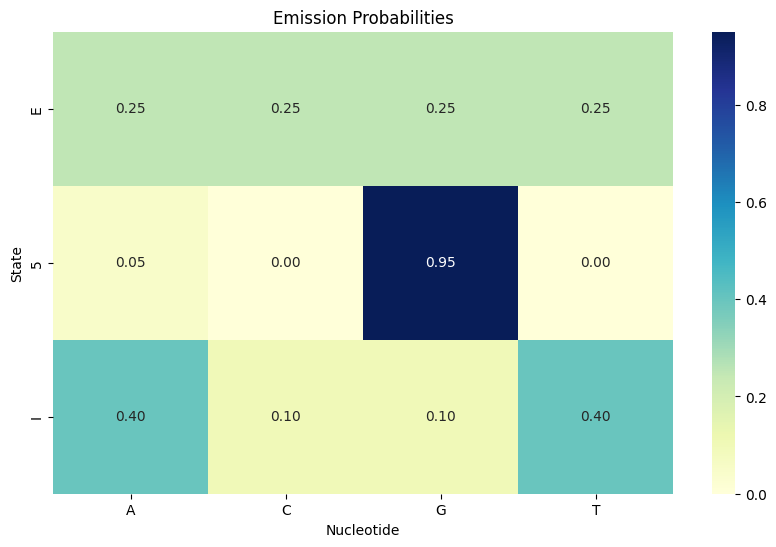

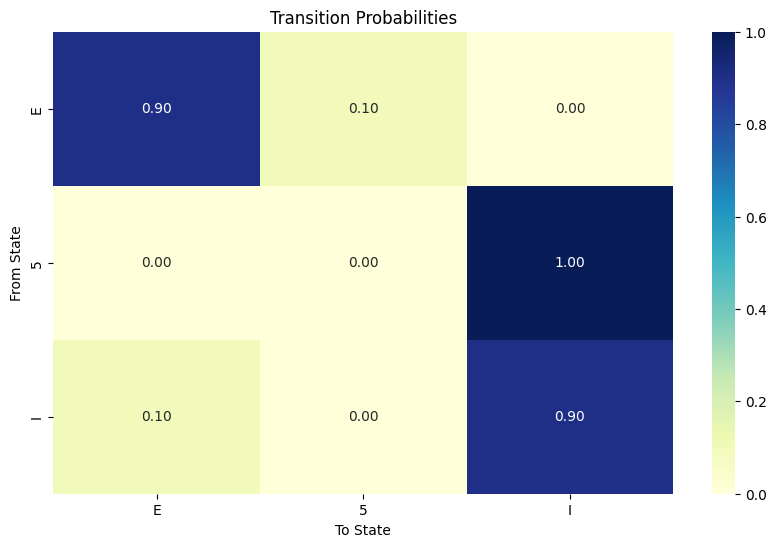

In [7]:
# Visualize emission probabilities
emission_df = pd.DataFrame(emission_probs).T

plt.figure(figsize=(10, 6))
sns.heatmap(emission_df, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Emission Probabilities')
plt.xlabel('Nucleotide')
plt.ylabel('State')
plt.show()

# Visualize transition probabilities
transition_df = pd.DataFrame(transition_probs).T

plt.figure(figsize=(10, 6))
sns.heatmap(transition_df, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Transition Probabilities')
plt.xlabel('To State')
plt.ylabel('From State')
plt.show()

## 6. Testing with Additional Sequences

Let's test our Viterbi implementation with additional sequences to observe different patterns.

In [8]:
# Define additional test sequences
test_sequences = [
    "AAAAAAAA",  # Should favor introns due to high A content
    "CCCCCCCC",  # Should favor exons
    "GGGGGGGG",  # Should include 5' splice site due to high G preference
    "ACGTACGT"   # Mixed sequence
]

# Test Viterbi on each sequence
for i, seq in enumerate(test_sequences):
    print(f"\nTest Sequence {i+1}: {seq}")
    path, prob = viterbi(seq)
    print(f"Most likely path: {path}")
    print(f"Log probability: {prob:.2f}")
    
    # Count states in the path
    state_counts = {state: path.count(state) for state in states}
    print(f"State counts: {state_counts}")


Test Sequence 1: AAAAAAAA
Most likely path: EEEEEEEE
Log probability: -11.83
State counts: {'E': 8, '5': 0, 'I': 0}

Test Sequence 2: CCCCCCCC
Most likely path: EEEEEEEE
Log probability: -11.83
State counts: {'E': 8, '5': 0, 'I': 0}

Test Sequence 3: GGGGGGGG
Most likely path: EEEEEEEE
Log probability: -11.83
State counts: {'E': 8, '5': 0, 'I': 0}

Test Sequence 4: ACGTACGT
Most likely path: EEEEEEEE
Log probability: -11.83
State counts: {'E': 8, '5': 0, 'I': 0}
